In [1]:
# 1. Import & Config
import sys, os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import InferenceConfig
from utils import setup_logging, setup_random_seed

logger = setup_logging()
logger.info("✓ Imports OK")

2026-07-24 18:41:21,470 - utils.setup - INFO - Logger is set up.
2026-07-24 18:41:21,471 - utils.setup - INFO - ✓ Imports OK


In [2]:


logger = setup_logging()
logger.info("✓ Imports OK")

# ── 1.1 Config ────────────────────────────────────────────────────────
cfg = InferenceConfig(
    name             = "portfolio_config",
    # group            = "set_index",
    # subgroup         = "set_idx50",
    # experiment_name  = "v1_trial01_w20a33_ddpm_warmup-cosine_optuna",
    group            = "sp_index",
    subgroup         = "sp_idx100",
    experiment_name  = "v1_trial01_w20a88_ddpm_warmup-cosine_optuna",

    checkpoint_file  = "best_model.pt",
    num_simulations  = 100,
    random_seed      = 72,
)
cfg = cfg.apply_experiment_config()

SPLIT = "train"
sim_dir = cfg.experiment_dir / "simulations" / f"{SPLIT}_all_n{cfg.num_simulations}"

print(f"  Experiment      : {cfg.experiment_name}")
print(f"  Simulation dir  : {sim_dir}")

2026-07-24 18:41:21,483 - utils.setup - INFO - Logger is set up.
2026-07-24 18:41:21,484 - utils.setup - INFO - ✓ Imports OK
[InferenceConfig] model_params loaded from best_params.json
  Experiment      : v1_trial01_w20a88_ddpm_warmup-cosine_optuna
  Simulation dir  : /home/narodom.y@FUSION.LAB/research/02_experiments/sp_index/sp_idx100/v1_trial01_w20a88_ddpm_warmup-cosine_optuna/simulations/train_all_n100


In [3]:

# 2. Load Simulation Data (Direct Array Load)
npz_path = sim_dir / "result_all_windows.npz"

if not npz_path.exists():
    raise FileNotFoundError(f"Not found: {npz_path} (รัน inferencing หรือยัง?)")

data = np.load(npz_path, allow_pickle=True)

# โหลด arrays (T = จำนวน window, N = sims, W = window_size, A = assets, C = channels)
all_prices_gen   = data["prices_gen"]       # (T, N, W, A)
all_prices_real  = data["prices_real"]      # (T, W, A)
all_log_ret_gen  = data["log_ret_gen"]      # (T, N, W, A, C)
all_log_ret_real = data["log_ret_real"]     # (T, W, A, C)
all_dates        = data["dates"]            # (T, W)
tickers          = data["tickers"]          # (A,)

T = all_prices_gen.shape[0]
N = all_prices_gen.shape[1]
W = all_prices_gen.shape[2]
A = all_prices_gen.shape[3]

print(f"  ✓ Loaded 1 file from {SPLIT}_all_n{cfg.num_simulations}")
print(f"  all_prices_gen   : {all_prices_gen.shape}")
print(f"  all_prices_real  : {all_prices_real.shape}")
print(f"  all_log_ret_gen  : {all_log_ret_gen.shape}")
print(f"  all_log_ret_real : {all_log_ret_real.shape}")
print(f"  all_dates        : {all_dates.shape}")
print(f"  tickers          : {len(tickers)} assets")

  ✓ Loaded 1 file from train_all_n100
  all_prices_gen   : (101, 100, 20, 88)
  all_prices_real  : (101, 20, 88)
  all_log_ret_gen  : (101, 100, 20, 88, 4)
  all_log_ret_real : (101, 20, 88, 4)
  all_dates        : (101,)
  tickers          : 88 assets


In [4]:
# ============================================================
# CELL A: Per-asset distribution stats + distance metrics
# ============================================================
from scipy import stats as sps
import pandas as pd

# --- config: index ของ channel "close" ใน all_log_ret_* (T,[N],W,A,C) ---
# สมมติ order channel คือ [open, high, low, close] -> close = index สุดท้าย
CLOSE_IDX = 0

out_dir = sim_dir / "analysis"
out_dir.mkdir(exist_ok=True)

# flatten ข้าม window (และ sims สำหรับ gen) -> ได้ sample distribution ต่อ asset
real_close = all_log_ret_real[..., CLOSE_IDX]        # (T, W, A)
real_flat  = real_close.reshape(-1, A)               # (T*W, A)

gen_close  = all_log_ret_gen[..., CLOSE_IDX]         # (T, N, W, A)
gen_flat   = gen_close.reshape(-1, A)                # (T*N*W, A)

print(f"real_flat: {real_flat.shape}  |  gen_flat: {gen_flat.shape}")

rows = []
for i, tk in enumerate(tickers):
    r = real_flat[:, i]; r = r[~np.isnan(r)]
    g = gen_flat[:, i];  g = g[~np.isnan(g)]

    w_dist = sps.wasserstein_distance(r, g)
    ks_stat, ks_p = sps.ks_2samp(r, g)

    rows.append({
        "ticker": tk,
        "real_mean": r.mean(),  "gen_mean": g.mean(),
        "real_std":  r.std(ddof=1), "gen_std": g.std(ddof=1),
        "real_skew": sps.skew(r),   "gen_skew": sps.skew(g),
        "real_kurt": sps.kurtosis(r, fisher=True),   # excess kurtosis, Normal=0
        "gen_kurt":  sps.kurtosis(g, fisher=True),
        "wasserstein": w_dist,
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
    })

stats_df = pd.DataFrame(rows).set_index("ticker")
stats_df["kurt_gap"] = (stats_df["gen_kurt"] - stats_df["real_kurt"]).abs()
stats_df["skew_gap"] = (stats_df["gen_skew"] - stats_df["real_skew"]).abs()

# overall pooled (ข้ามทั้ง asset+window) เหมือนกราฟรวมในรูปที่ 2
r_all = real_flat.flatten(); r_all = r_all[~np.isnan(r_all)]
g_all = gen_flat.flatten();  g_all = g_all[~np.isnan(g_all)]
print(f"\n[Overall pooled] real μ={r_all.mean():.5f} σ={r_all.std():.5f} "
      f"skew={sps.skew(r_all):.3f} kurt={sps.kurtosis(r_all):.3f}")
print(f"[Overall pooled] gen  μ={g_all.mean():.5f} σ={g_all.std():.5f} "
      f"skew={sps.skew(g_all):.3f} kurt={sps.kurtosis(g_all):.3f}")
print(f"[Overall pooled] Wasserstein={sps.wasserstein_distance(r_all, g_all):.5f}  "
      f"KS={sps.ks_2samp(r_all, g_all)[0]:.4f}")

stats_df.to_csv(out_dir / "per_asset_dist_stats.csv")
stats_df.sort_values("wasserstein")

real_flat: (2020, 88)  |  gen_flat: (202000, 88)



[Overall pooled] real μ=0.00044 σ=0.01491 skew=-0.133 kurt=22.820
[Overall pooled] gen  μ=0.00034 σ=0.01426 skew=-0.153 kurt=12.315
[Overall pooled] Wasserstein=0.00039  KS=0.0118


,real_mean,gen_mean,real_std,gen_std,real_skew,gen_skew,real_kurt,gen_kurt,wasserstein,ks_stat,ks_pvalue,kurt_gap,skew_gap
ticker,,,,,,,,,,,,,
PG,0.000285,0.000290,0.009237,0.008851,0.062927,-0.196993,6.440413,4.857409,0.000244,0.013431,0.858520,1.583004,0.259920
GD,0.000462,0.000362,0.012534,0.012333,-0.262150,-0.243849,3.434407,4.259248,0.000283,0.011767,0.941538,0.824841,0.018301
KO,0.000302,0.000421,0.009055,0.008699,-0.422991,-0.278614,3.713128,3.816041,0.000303,0.018827,0.471940,0.102913,0.144377
MCD,0.000512,0.000545,0.009864,0.009615,0.295603,-0.280989,6.150939,6.366996,0.000308,0.014475,0.790412,0.216057,0.576592
MO,0.000515,0.000715,0.010756,0.010427,-0.787277,-0.427874,6.216684,4.790977,0.000310,0.016366,0.651418,1.425707,0.359403
...,...,...,...,...,...,...,...,...,...,...,...,...,...
BAC,0.000340,-0.000310,0.020781,0.019463,-0.499769,-0.126127,11.224396,5.993052,0.000880,0.028094,0.083495,5.231343,0.373642
C,0.000050,-0.000428,0.019398,0.018273,-0.521133,-0.145045,7.483262,5.295506,0.000949,0.027743,0.090335,2.187756,0.376088
MS,0.000223,-0.000401,0.021351,0.020162,-0.140421,-0.073499,6.342150,5.311727,0.000992,0.022267,0.270489,1.030423,0.066922


In [5]:
# ============================================================
# CELL B: เลือก asset ที่ gen "จับทรง non-Gaussian" ของ real ได้ดีที่สุด
# ============================================================
# เกณฑ์: (1) real ต้องไม่ guassian จริง (excess kurtosis สูงพอ ไม่งั้นเทียบไม่มีความหมาย)
#        (2) wasserstein/ks distance ต่ำ  (3) skew/kurtosis gap ต่ำ

MIN_REAL_KURT = 1.0   # threshold ความ fat-tail ของ real ที่สนใจ (ปรับได้)

candidates = stats_df[stats_df["real_kurt"] > MIN_REAL_KURT].copy()
print(f"asset ที่ real มี fat-tail ชัด (excess kurt > {MIN_REAL_KURT}): {len(candidates)}/{A}")

rank_cols = ["wasserstein", "ks_stat", "kurt_gap", "skew_gap"]
for c in rank_cols:
    candidates[f"{c}_rank"] = candidates[c].rank()
candidates["composite_score"] = candidates[[f"{c}_rank" for c in rank_cols]].mean(axis=1)

best_assets = candidates.sort_values("composite_score").head(8)
cols_show = ["real_kurt","gen_kurt","real_skew","gen_skew","wasserstein","ks_stat","composite_score"]
print("\nTop 8 best non-Gaussian captures:")
best_assets[cols_show]

asset ที่ real มี fat-tail ชัด (excess kurt > 1.0): 88/88

Top 8 best non-Gaussian captures:


,real_kurt,gen_kurt,real_skew,gen_skew,wasserstein,ks_stat,composite_score
ticker,,,,,,,
GD,3.434407,4.259248,-0.262150,-0.243849,0.000283,0.011767,7.25
NEE,2.648360,2.307360,-0.224910,-0.251228,0.000394,0.018153,12.00
KO,3.713128,3.816041,-0.422991,-0.278614,0.000303,0.018827,14.50
EMR,3.126763,3.476180,-0.206692,-0.195044,0.000387,0.020866,15.50
CL,4.358376,4.965369,-0.301915,-0.330210,0.000457,0.018238,17.50
HD,2.604180,3.700437,-0.135433,-0.236546,0.000354,0.012995,18.00
SBUX,7.813401,8.254825,-0.277838,-0.214103,0.000498,0.019218,22.25
MCD,6.150939,6.366996,0.295603,-0.280989,0.000308,0.014475,22.75


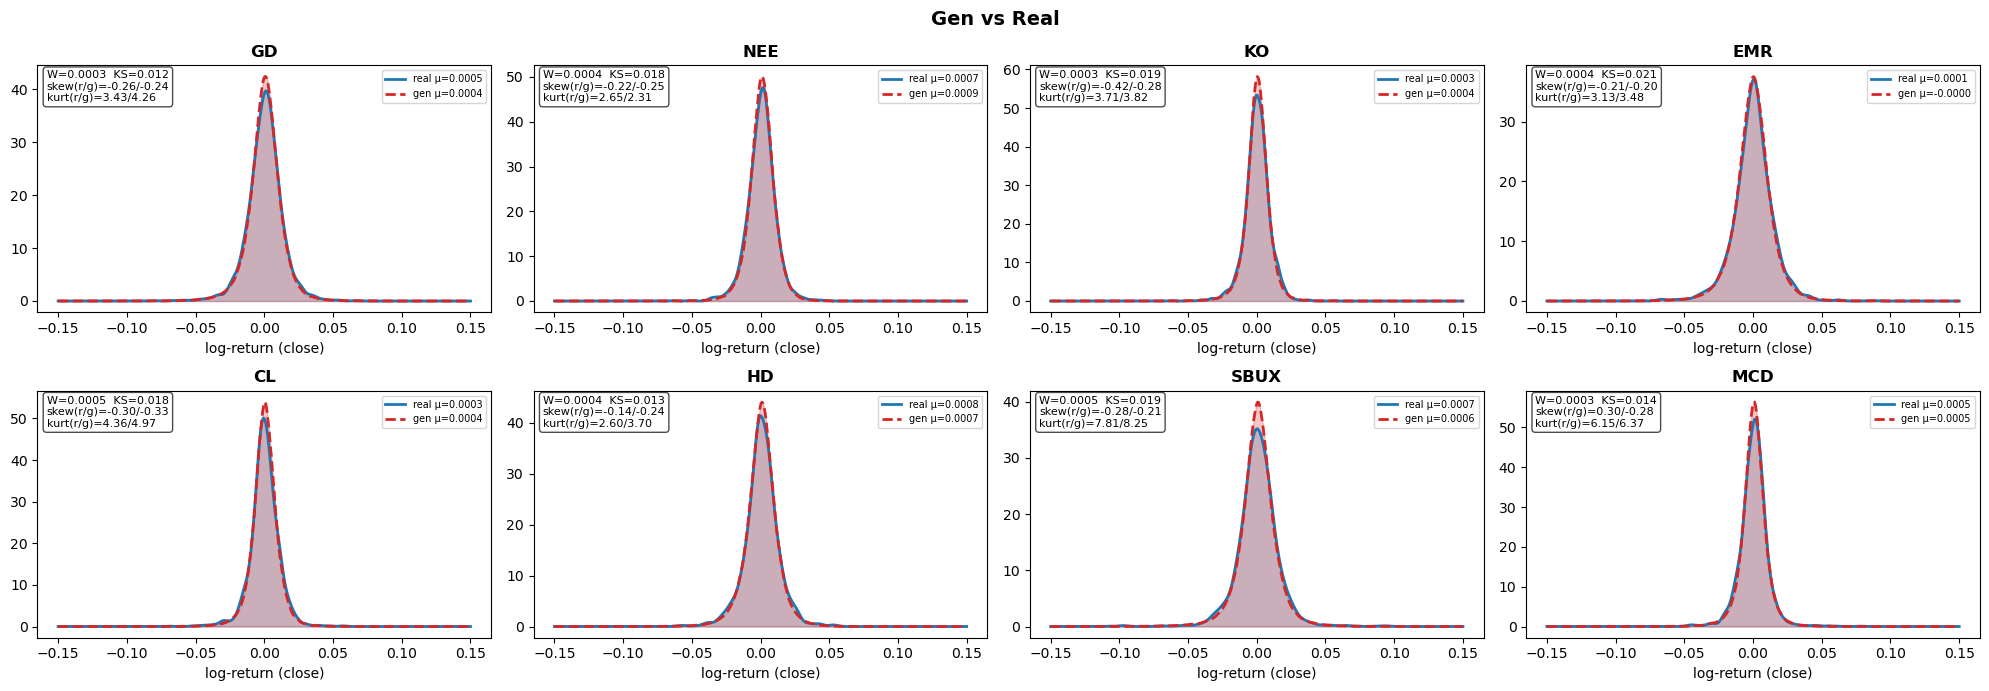

In [6]:
# ============================================================
# CELL C: Plot เฉพาะ best assets (KDE overlay + stats annotation)
# ============================================================
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

best_tickers = best_assets.index.tolist()
ncols = 4
nrows = int(np.ceil(len(best_tickers) / ncols))
x_grid = np.linspace(-0.15, 0.15, 400)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
axes = np.array(axes).reshape(-1)

for ax, tk in zip(axes, best_tickers):
    i = list(tickers).index(tk)
    r = real_flat[:, i]; r = r[~np.isnan(r)]
    g = gen_flat[:, i];  g = g[~np.isnan(g)]

    kde_r = gaussian_kde(r)(x_grid)
    kde_g = gaussian_kde(g)(x_grid)

    ax.plot(x_grid, kde_r, color="tab:blue", lw=2, label=f"real μ={r.mean():.4f}")
    ax.fill_between(x_grid, kde_r, color="tab:blue", alpha=0.25)
    ax.plot(x_grid, kde_g, color="tab:red", lw=2, ls="--", label=f"gen μ={g.mean():.4f}")
    ax.fill_between(x_grid, kde_g, color="tab:red", alpha=0.25)

    s = stats_df.loc[tk]
    txt = (f"W={s.wasserstein:.4f}  KS={s.ks_stat:.3f}\n"
           f"skew(r/g)={s.real_skew:.2f}/{s.gen_skew:.2f}\n"
           f"kurt(r/g)={s.real_kurt:.2f}/{s.gen_kurt:.2f}")
    ax.text(0.02, 0.98, txt, transform=ax.transAxes, va="top", ha="left", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))
    ax.set_title(tk, fontweight="bold")
    ax.legend(fontsize=7, loc="upper right")
    ax.set_xlabel("log-return (close)")

for ax in axes[len(best_tickers):]:
    ax.axis("off")

fig.suptitle("Gen vs Real", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(out_dir / "best_nongaussian_dist.png", dpi=150, bbox_inches="tight")
plt.show()

[Pooled, all windows] Corr MAE=0.0338  RMSE=0.0439  Frobenius=3.8400


[Per-window] Corr MAE: mean=0.1891  std=0.0432  min=0.1098  max=0.3194


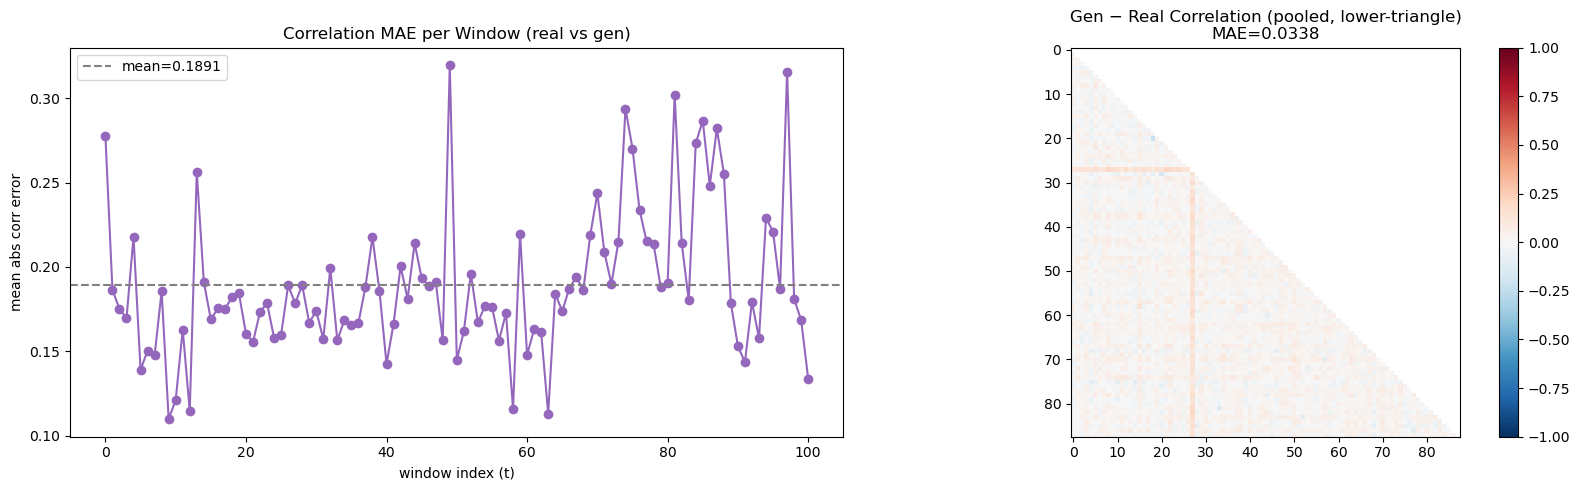

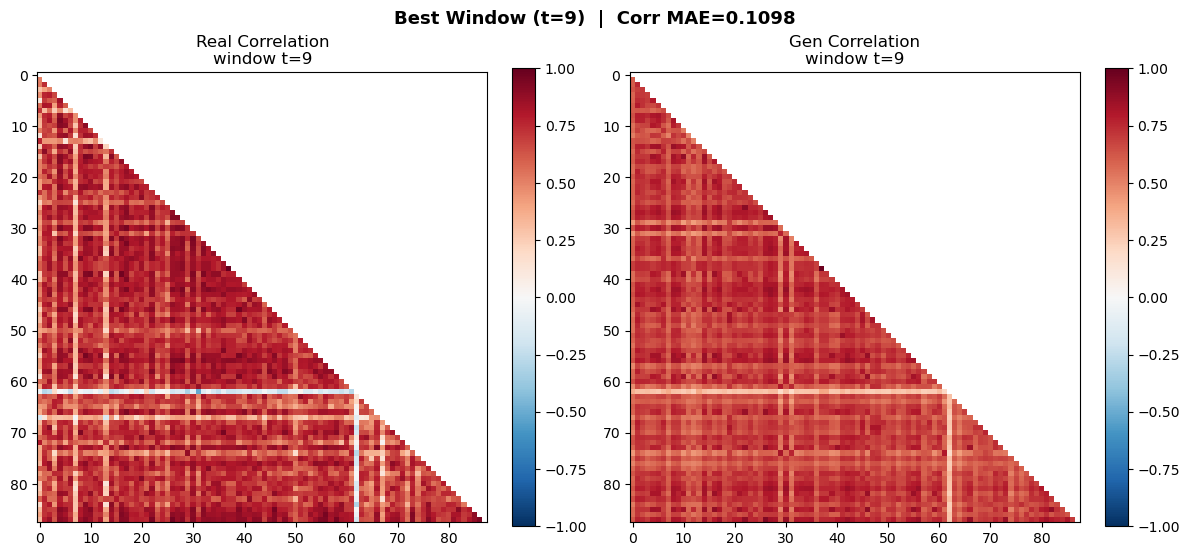

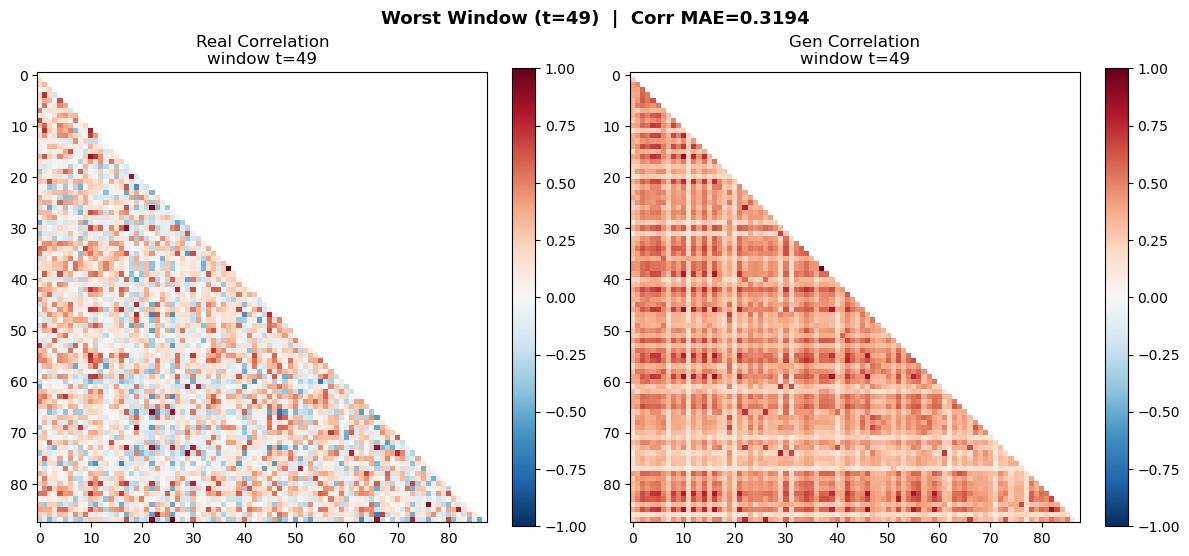

In [7]:
# ============================================================
# CELL D: Correlation — pooled (all windows) + per-window stability
# ============================================================
iu = np.triu_indices(A, k=1)

# --- pooled correlation (ใช้ real_flat / gen_flat ที่ flatten ทุก window แล้ว) ---
real_corr = np.corrcoef(real_flat, rowvar=False)
gen_corr  = np.corrcoef(gen_flat,  rowvar=False)

corr_mae  = np.mean(np.abs(gen_corr[iu] - real_corr[iu]))
corr_rmse = np.sqrt(np.mean((gen_corr[iu] - real_corr[iu])**2))
corr_frob = np.linalg.norm(gen_corr - real_corr, ord="fro")
print(f"[Pooled, all windows] Corr MAE={corr_mae:.4f}  RMSE={corr_rmse:.4f}  Frobenius={corr_frob:.4f}")

# --- per-window correlation: เพื่อดูว่า capture ดีตลอดทุก window จริงไหม ---
N_SIMS_FOR_CORR = min(200, N)   # subsample sims กัน loop ช้าเกิน (ปรับได้ตามเวลาที่มี)
per_window_mae = np.zeros(T)

for t in range(T):
    r_t = all_log_ret_real[t, :, :, CLOSE_IDX]                 # (W, A)
    r_corr_t = np.corrcoef(r_t, rowvar=False)

    g_t = all_log_ret_gen[t, :N_SIMS_FOR_CORR, :, :, CLOSE_IDX]  # (n, W, A)
    g_corr_t = np.mean([np.corrcoef(g_t[n], rowvar=False) for n in range(g_t.shape[0])], axis=0)

    per_window_mae[t] = np.mean(np.abs(g_corr_t[iu] - r_corr_t[iu]))

print(f"[Per-window] Corr MAE: mean={per_window_mae.mean():.4f}  std={per_window_mae.std():.4f}  "
      f"min={per_window_mae.min():.4f}  max={per_window_mae.max():.4f}")

# --- mask สามเหลี่ยมบน (รวม diagonal) ให้เหลือแค่ lower-triangle ---
mask_upper = np.triu(np.ones((A, A), dtype=bool), k=0)

def masked(mat):
    m = mat.copy()
    m[mask_upper] = np.nan
    return m

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(per_window_mae, marker="o", color="tab:purple")
axes[0].axhline(per_window_mae.mean(), color="gray", ls="--", label=f"mean={per_window_mae.mean():.4f}")
axes[0].set_title("Correlation MAE per Window (real vs gen)")
axes[0].set_xlabel("window index (t)"); axes[0].set_ylabel("mean abs corr error")
axes[0].legend()

im = axes[1].imshow(masked(gen_corr - real_corr), cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title(f"Gen − Real Correlation (pooled, lower-triangle)\nMAE={corr_mae:.4f}")
fig.colorbar(im, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(out_dir / "corr_stability_per_window.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# CELL D-2: Best / Worst window — Real vs Gen correlation (lower-triangle)
# ============================================================
t_best  = int(np.argmin(per_window_mae))   # window ที่ gen เลียน corr ของ real ได้ดีที่สุด
t_worst = int(np.argmax(per_window_mae))   # window ที่ gen เลียน corr ของ real แย่ที่สุด

def window_corrs(t):
    r_t = all_log_ret_real[t, :, :, CLOSE_IDX]                     # (W, A)
    r_corr_t = np.corrcoef(r_t, rowvar=False)

    g_t = all_log_ret_gen[t, :N_SIMS_FOR_CORR, :, :, CLOSE_IDX]    # (n, W, A)
    g_corr_t = np.mean([np.corrcoef(g_t[n], rowvar=False) for n in range(g_t.shape[0])], axis=0)
    return r_corr_t, g_corr_t

for label, t_idx in [("Best", t_best), ("Worst", t_worst)]:
    r_corr_t, g_corr_t = window_corrs(t_idx)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

    im0 = axes[0].imshow(masked(r_corr_t), cmap="RdBu_r", vmin=-1, vmax=1)
    axes[0].set_title(f"Real Correlation\nwindow t={t_idx}")
    fig.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(masked(g_corr_t), cmap="RdBu_r", vmin=-1, vmax=1)
    axes[1].set_title(f"Gen Correlation\nwindow t={t_idx}")
    fig.colorbar(im1, ax=axes[1], fraction=0.046)

    fig.suptitle(f"{label} Window (t={t_idx})  |  Corr MAE={per_window_mae[t_idx]:.4f}",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(out_dir / f"corr_{label.lower()}_window_t{t_idx}.png", dpi=150, bbox_inches="tight")
    plt.show()